# RTX 4050 Laptop GPU — CUDA anatomy lab

This notebook lets you inspect and *measure* your GPU rather than relying on a spec sheet. You will see:

- compute capability, SM count, memory hierarchy, clocks, and hardware limits;
- how grids, block-like Triton programs, warps, and logical lanes fit together;
- which SM actually executes each program, read directly from the `%smid` hardware register;
- how tile size and warps per program affect a memory-bound kernel;
- generated PTX and SASS, plus a small Tensor Core-friendly matrix benchmark.

## 1. Environment and CUDA device

In [2]:
import math
import time
import shutil
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import triton
import triton.language as tl

architecture_names = {
    (7, 5): "Turing",
    (8, 0): "Ampere (A100-class)",
    (8, 6): "Ampere (consumer-class)",
    (8, 9): "Ada Lovelace",
    (9, 0): "Hopper",
    (10, 0): "Blackwell",
    (12, 0): "Blackwell",
}

In [3]:
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not visible. In VS Code, choose the project's .venv Python kernel, "
        "then verify that `uv run python -c \"import torch; print(torch.cuda.is_available())\"` prints True."
    )

DEVICE_INDEX = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{DEVICE_INDEX}")
props = torch.cuda.get_device_properties(DEVICE_INDEX)
torch.manual_seed(0)

print(f"PyTorch:             {torch.__version__}")
print(f"PyTorch CUDA build:  {torch.version.cuda}")
print(f"Triton:              {triton.__version__}")
print(f"Device:              {props.name}")
print(f"Compute capability:  {props.major}.{props.minor} (sm_{props.major}{props.minor})")
print(f"CUDA architectures compiled into PyTorch: {torch.cuda.get_arch_list()}")

PyTorch:             2.12.1+cu130
PyTorch CUDA build:  13.0
Triton:              3.7.1
Device:              NVIDIA GeForce RTX 4050 Laptop GPU
Compute capability:  8.9 (sm_89)
CUDA architectures compiled into PyTorch: ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 2. Static chip details reported by the CUDA runtime

An **SM** (streaming multiprocessor) is the main scheduling/compute unit. A **warp** is 32 threads executing together. Threads and blocks are launch/scheduling concepts; they are not the same thing as CUDA cores.


In [5]:
cc = (props.major, props.minor)

architecture = architecture_names.get(cc, "Unknown/new architecture")
warp_size = props.warp_size
max_threads_sm = props.max_threads_per_multi_processor
warps_per_sm = max_threads_sm // warp_size
sm_count = props.multi_processor_count

# CUDA reports the memory clock in kHz. GDDR transfers on both clock edges, hence * 2.
approx_peak_bandwidth_gbs = (
    props.memory_clock_rate * 1_000 * 2 * (props.memory_bus_width / 8) / 1e9
)

facts = [
    ("Architecture", architecture, "decoded from compute capability"),
    ("Compute capability", f"{props.major}.{props.minor}", "CUDA feature/instruction target"),
    ("Streaming multiprocessors (SMs)", sm_count, "independent scheduling/compute units"),
    ("Warp size", warp_size, "threads"),
    ("Max threads / block", props.max_threads_per_block, "hard launch limit"),
    ("Max resident threads / SM", max_threads_sm, "subject to register/shared-memory limits"),
    ("Max resident warps / SM", warps_per_sm, "thread limit divided by warp size"),
    ("Register file / SM", f"{props.regs_per_multiprocessor:,}", "32-bit registers"),
    ("Shared memory / block", f"{props.shared_memory_per_block / 1024:.0f} KiB", "default limit"),
    ("Opt-in shared memory / block", f"{props.shared_memory_per_block_optin / 1024:.0f} KiB", "requires opt-in"),
    ("Shared memory / SM", f"{props.shared_memory_per_multiprocessor / 1024:.0f} KiB", "shared among resident blocks"),
    ("L2 cache", f"{props.L2_cache_size / 2**20:.1f} MiB", "shared across the GPU"),
    ("VRAM visible to CUDA", f"{props.total_memory / 2**30:.2f} GiB", "usable value can be lower than marketed capacity"),
    ("Memory bus width", f"{props.memory_bus_width} bit", "GDDR interface width"),
    ("Reported max SM clock", f"{props.clock_rate / 1e6:.3f} GHz", "power/thermal state changes live clock"),
    ("Approx. peak memory bandwidth", f"{approx_peak_bandwidth_gbs:.1f} GB/s", "clock × DDR × bus width"),
]
hardware_df = pd.DataFrame(facts, columns=["Property", "Value", "Meaning"])
hardware_df


,Property,Value,Meaning
0,Architecture,Ada Lovelace,decoded from compute capability
1,Compute capability,8.9,CUDA feature/instruction target
2,Streaming multiprocessors (SMs),20,independent scheduling/compute units
3,Warp size,32,threads
4,Max threads / block,1024,hard launch limit
5,Max resident threads / SM,1536,subject to register/shared-memory limits
6,Max resident warps / SM,48,thread limit divided by warp size
7,Register file / SM,"65,536",32-bit registers
8,Shared memory / block,48 KiB,default limit
9,Opt-in shared memory / block,99 KiB,requires opt-in


In [8]:
free_bytes, total_bytes = torch.cuda.mem_get_info(DEVICE_INDEX)
print(f"Current free VRAM:      {free_bytes / 2**30:.2f} GiB / {total_bytes / 2**30:.2f} GiB")
print(f"PyTorch allocated:      {torch.cuda.memory_allocated(DEVICE) / 2**20:.1f} MiB")
print(f"PyTorch cache reserved: {torch.cuda.memory_reserved(DEVICE) / 2**20:.1f} MiB")
print(f"Thread-slot ceiling:    {sm_count * max_threads_sm:,} resident threads across all SMs")
print(f"Warp-slot ceiling:      {sm_count * warps_per_sm:,} resident warps across all SMs")
print("\nThese are residency ceilings, not the number of operations that execute simultaneously.")


Current free VRAM:      5.54 GiB / 5.64 GiB
PyTorch allocated:      0.0 MiB
PyTorch cache reserved: 0.0 MiB
Thread-slot ceiling:    30,720 resident threads across all SMs
Warp-slot ceiling:      960 resident warps across all SMs

These are residency ceilings, not the number of operations that execute simultaneously.


### Threads per block and the first occupancy constraint

The table below applies only the resident-thread limit. Real occupancy can be lower because a kernel also consumes registers, shared memory, warp slots, and block slots. This is why `1024 threads/block` is legal but often not the fastest launch.


In [9]:
occupancy_rows = []
for threads_per_block in [32, 64, 128, 256, 512, 768, 1024]:
    blocks_from_thread_limit = max_threads_sm // threads_per_block
    resident_threads = blocks_from_thread_limit * threads_per_block
    occupancy_rows.append({
        "threads/block": threads_per_block,
        "warps/block": math.ceil(threads_per_block / warp_size),
        "blocks/SM (thread limit only)": blocks_from_thread_limit,
        "resident threads/SM": resident_threads,
        "thread-slot use": f"{100 * resident_threads / max_threads_sm:.1f}%",
    })
pd.DataFrame(occupancy_rows)


,threads/block,warps/block,blocks/SM (thread limit only),resident threads/SM,thread-slot use
0,32,1,48,1536,100.0%
1,64,2,24,1536,100.0%
2,128,4,12,1536,100.0%
3,256,8,6,1536,100.0%
4,512,16,3,1536,100.0%
5,768,24,2,1536,100.0%
6,1024,32,1,1024,66.7%


## 3. Live clocks, power, temperature, and driver state

`nvidia-smi` uses NVIDIA's management interface, while PyTorch uses the CUDA runtime. On some sandboxed or containerized setups PyTorch can see CUDA even when `nvidia-smi` is unavailable, so this cell handles that case without stopping the notebook.


In [10]:
query_fields = [
    "name", "driver_version", "pstate", "temperature.gpu",
    "power.draw", "power.limit", "clocks.current.graphics",
    "clocks.current.memory", "utilization.gpu", "utilization.memory",
    "memory.used", "memory.total",
]
cmd = [
    "nvidia-smi",
    f"--query-gpu={','.join(query_fields)}",
    "--format=csv,noheader",
]
try:
    result = subprocess.run(cmd, check=True, capture_output=True, text=True)
    values = [value.strip() for value in result.stdout.strip().split(",")]
    live_df = pd.DataFrame({"Field": query_fields, "Live value": values})
    print(live_df.to_string(index=False))
except (FileNotFoundError, subprocess.CalledProcessError) as exc:
    detail = getattr(exc, "stderr", "") or str(exc)
    print("nvidia-smi is unavailable here; CUDA runtime experiments can still run.")
    print(detail.strip())


                  Field                         Live value
                   name NVIDIA GeForce RTX 4050 Laptop GPU
         driver_version                          595.71.05
                 pstate                                 P8
        temperature.gpu                                 49
             power.draw                             1.83 W
            power.limit                              [N/A]
clocks.current.graphics                            210 MHz
  clocks.current.memory                            405 MHz
        utilization.gpu                                0 %
     utilization.memory                                0 %
            memory.used                            102 MiB
           memory.total                           6141 MiB


## 4. Grid → program/block → warp → logical element

Triton calls a block-like unit a **program instance**. On NVIDIA's CUDA backend it is compiled as a CTA (CUDA block). `BLOCK_SIZE` below is the number of logical data elements handled by a program—not necessarily the physical CUDA thread count. `num_warps=1` requests one 32-thread warp for each program.

With 70 elements and a logical tile of 32, the grid contains `ceil(70 / 32) = 3` programs. The last program is masked after element 69.


In [11]:
@triton.jit
def launch_map_kernel(program_ids, logical_lanes, n_elements: tl.constexpr, BLOCK_SIZE: tl.constexpr):
    program_id = tl.program_id(axis=0)
    logical_lane = tl.arange(0, BLOCK_SIZE)
    offsets = program_id * BLOCK_SIZE + logical_lane
    mask = offsets < n_elements
    tl.store(program_ids + offsets, program_id, mask=mask)
    tl.store(logical_lanes + offsets, logical_lane, mask=mask)

N_MAP = 70
LOGICAL_BLOCK_SIZE = 32
GRID = (triton.cdiv(N_MAP, LOGICAL_BLOCK_SIZE),)
program_ids = torch.empty(N_MAP, device=DEVICE, dtype=torch.int32)
logical_lanes = torch.empty_like(program_ids)

launch_map_kernel[GRID](
    program_ids, logical_lanes,
    n_elements=N_MAP, BLOCK_SIZE=LOGICAL_BLOCK_SIZE, num_warps=1,
)
torch.cuda.synchronize()

mapping_df = pd.DataFrame({
    "global element": np.arange(N_MAP),
    "program / block-like ID": program_ids.cpu().numpy(),
    "logical lane in tile": logical_lanes.cpu().numpy(),
})
print(f"Grid: {GRID[0]} programs, logical tile: {LOGICAL_BLOCK_SIZE}, requested physical threads/program: {warp_size}")
pd.concat([mapping_df.head(36), mapping_df.tail(10)])


Grid: 3 programs, logical tile: 32, requested physical threads/program: 32


,global element,program / block-like ID,logical lane in tile
0,0,0,0
1,1,0,1
2,2,0,2
3,3,0,3
4,4,0,4
5,5,0,5
6,6,0,6
7,7,0,7
8,8,0,8
9,9,0,9


## 5. Read the physical SM ID from hardware

The next kernel uses inline PTX to execute `mov.u32 ..., %smid`. Each program records the physical SM on which it ran. Re-run the cell: distribution can change because block scheduling is dynamic. A nearly empty GPU usually touches all SMs for a sufficiently large grid, but the per-SM counts are only a scheduling snapshot.


Observed 20 / 20 SMs while scheduling 640 tiny programs.
 SM ID  programs observed
     0                 34
     1                 30
     2                 31
     3                 34
     4                 31
     5                 35
     6                 29
     7                 33
     8                 34
     9                 33
    10                 35
    11                 31
    12                 34
    13                 29
    14                 29
    15                 33
    16                 31
    17                 34
    18                 27
    19                 33


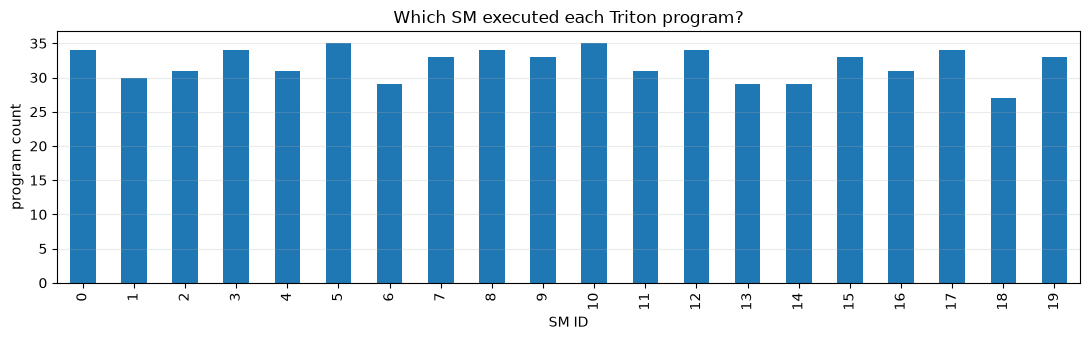

In [ ]:
@triton.jit
def smid_probe_kernel(smids, n_programs: tl.constexpr):
    program_id = tl.program_id(axis=0)
    smid = tl.inline_asm_elementwise(
        "mov.u32 $0, %smid;",
        "=r",
        [],
        dtype=tl.int32,
        is_pure=False,
        pack=1,
    )
    tl.store(smids + program_id, smid, mask=program_id < n_programs)

N_PROGRAMS = sm_count * 32
smids = torch.empty(N_PROGRAMS, device=DEVICE, dtype=torch.int32)
smid_probe_kernel[(N_PROGRAMS,)](smids, n_programs=N_PROGRAMS, num_warps=1)
torch.cuda.synchronize()

unique_smids, counts = torch.unique(smids.cpu(), return_counts=True)
sm_schedule_df = pd.DataFrame({
    "SM ID": unique_smids.numpy(),
    "programs observed": counts.numpy(),
})
print(f"Observed {len(unique_smids)} / {sm_count} SMs while scheduling {N_PROGRAMS} tiny programs.")
print(sm_schedule_df.to_string(index=False))

ax = sm_schedule_df.plot.bar(x="SM ID", y="programs observed", figsize=(11, 3.5), legend=False)
ax.set_title("Which SM executed each Triton program?")
ax.set_ylabel("program count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Launch-shape experiment: tiles and physical warps

This vector-add kernel is memory-bound: it reads `x` and `y`, then writes `out` (12 bytes per FP32 element). We vary both the logical tile and physical warps per program. The effective GB/s includes those three arrays.

The best setting is workload- and kernel-specific. Bigger blocks can reduce scheduling overhead, while extra warps can improve latency hiding but increase resource pressure.


In [15]:
@triton.jit
def vector_add_kernel(x, y, out, n_elements, BLOCK_SIZE: tl.constexpr):
    program_id = tl.program_id(axis=0)
    offsets = program_id * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x_values = tl.load(x + offsets, mask=mask)
    y_values = tl.load(y + offsets, mask=mask)
    tl.store(out + offsets, x_values + y_values, mask=mask)

def launch_vector_add(x, y, out, block_size, num_warps):
    grid = (triton.cdiv(x.numel(), block_size),)
    vector_add_kernel[grid](
        x, y, out, x.numel(),
        BLOCK_SIZE=block_size, num_warps=num_warps,
    )

N = 2**23  # 8,388,608 FP32 elements: 32 MiB per tensor
x = torch.randn(N, device=DEVICE, dtype=torch.float32)
y = torch.randn_like(x)
out = torch.empty_like(x)

results = []
for block_size in [128, 256, 512, 1024]:
    for num_warps in [1, 2, 4, 8]:
        launch_vector_add(x, y, out, block_size, num_warps)
        torch.cuda.synchronize()
        ms = triton.testing.do_bench(
            lambda: launch_vector_add(x, y, out, block_size, num_warps),
            warmup=50,
            rep=150,
        )
        bytes_moved = 3 * N * x.element_size()
        results.append({
            "logical tile": block_size,
            "warps/program": num_warps,
            "physical threads/program": num_warps * warp_size,
            "grid programs": triton.cdiv(N, block_size),
            "latency (ms)": ms,
            "effective GB/s": bytes_moved / (ms * 1e-3) / 1e9,
        })

torch.testing.assert_close(out, x + y)
launch_results_df = pd.DataFrame(results).sort_values("effective GB/s", ascending=False)
launch_results_df.style.format({"latency (ms)": "{:.4f}", "effective GB/s": "{:.1f}"})


,logical tile,warps/program,physical threads/program,grid programs,latency (ms),effective GB/s
14,1024,4,128,8192,0.5969,168.6
9,512,2,64,16384,0.5973,168.5
10,512,4,128,16384,0.5978,168.4
8,512,1,32,16384,0.5982,168.3
12,1024,1,32,8192,0.5982,168.3
15,1024,8,256,8192,0.5986,168.2
4,256,1,32,32768,0.5986,168.2
13,1024,2,64,8192,0.5987,168.1
5,256,2,64,32768,0.5993,168.0
3,128,8,256,65536,0.6040,166.7


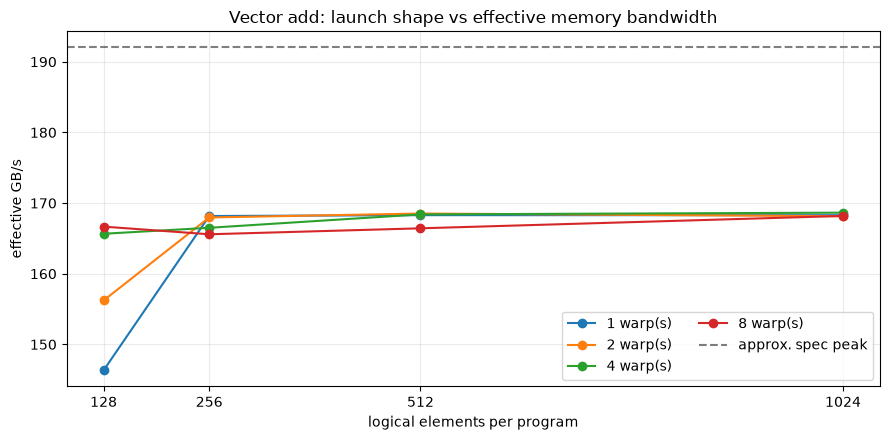

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for num_warps, group in launch_results_df.sort_values("logical tile").groupby("warps/program"):
    ax.plot(group["logical tile"], group["effective GB/s"], marker="o", label=f"{num_warps} warp(s)")
ax.axhline(approx_peak_bandwidth_gbs, color="black", linestyle="--", alpha=0.5, label="approx. spec peak")
ax.set_title("Vector add: launch shape vs effective memory bandwidth")
ax.set_xlabel("logical elements per program")
ax.set_ylabel("effective GB/s")
ax.set_xticks([128, 256, 512, 1024])
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## 7. Inspect what the compiler generated

PTX is NVIDIA's virtual instruction set. The driver lowers PTX to native machine instructions called **SASS**, stored in a cubin. The metadata also shows the exact architecture target, warp count, stages, and shared-memory use. Compiler output varies with Triton/PyTorch/CUDA versions.


In [17]:
INSPECT_BLOCK_SIZE = 256
INSPECT_NUM_WARPS = 4
compiled = vector_add_kernel.warmup(
    x, y, out, N,
    BLOCK_SIZE=INSPECT_BLOCK_SIZE,
    num_warps=INSPECT_NUM_WARPS,
    grid=(triton.cdiv(N, INSPECT_BLOCK_SIZE),),
)
metadata = compiled.metadata
print(f"Kernel name:       {metadata.name}")
print(f"Target:            {metadata.target}")
print(f"Architecture:      {metadata.arch}")
print(f"Warps / program:   {metadata.num_warps}")
print(f"Threads / program: {metadata.num_warps * metadata.warp_size}")
print(f"Compiler stages:   {metadata.num_stages}")
print(f"Shared memory:     {metadata.shared} bytes")
print(f"Available forms:   {list(compiled.asm)}")

ptx = compiled.asm["ptx"]
print("\n--- First 90 lines of generated PTX ---")
print("\n".join(ptx.splitlines()[:90]))


Kernel name:       vector_add_kernel
Target:            GPUTarget(backend='cuda', arch=89, warp_size=32)
Architecture:      sm89
Warps / program:   4
Threads / program: 128
Compiler stages:   3
Shared memory:     0 bytes
Available forms:   ['source', 'ttir', 'ttgir', 'llir', 'ptx', 'cubin']

--- First 90 lines of generated PTX ---
//
// Generated by LLVM NVPTX Back-End
//

.version 8.7
.target sm_89
.address_size 64

	// .globl	vector_add_kernel       // -- Begin function vector_add_kernel
                                        // @vector_add_kernel
.visible .entry vector_add_kernel(
	.param .u64 .ptr .global .align 1 vector_add_kernel_param_0,
	.param .u64 .ptr .global .align 1 vector_add_kernel_param_1,
	.param .u64 .ptr .global .align 1 vector_add_kernel_param_2,
	.param .u32 vector_add_kernel_param_3,
	.param .u64 .ptr .global .align 1 vector_add_kernel_param_4,
	.param .u64 .ptr .global .align 1 vector_add_kernel_param_5
)
.reqntid 128
{
	.reg .pred 	%p<2>;
	.reg .b32 	%r<14>;
	.

In [18]:
cuobjdump = shutil.which("cuobjdump")
if cuobjdump is None:
    print("cuobjdump is not installed; PTX above is still available.")
else:
    with tempfile.TemporaryDirectory() as temp_dir:
        cubin_path = Path(temp_dir) / "vector_add.cubin"
        cubin_path.write_bytes(compiled.asm["cubin"])
        sass_result = subprocess.run(
            [cuobjdump, "--dump-sass", str(cubin_path)],
            capture_output=True, text=True,
        )
        if sass_result.returncode == 0:
            print("--- First 120 lines of native SASS ---")
            print("\n".join(sass_result.stdout.splitlines()[:120]))
        else:
            print("cuobjdump could not decode this cubin (often a toolkit-version mismatch):")
            print(sass_result.stderr.strip())


--- First 120 lines of native SASS ---

	code for sm_89
		Function : vector_add_kernel
	.headerflags	@"EF_CUDA_TEXMODE_UNIFIED EF_CUDA_64BIT_ADDRESS EF_CUDA_SM89 EF_CUDA_VIRTUAL_SM(EF_CUDA_SM89)"
        /*0000*/                   MOV R1, c[0x0][0x28] ;                              /* 0x00000a0000017a02 */
                                                                                       /* 0x000fe40000000f00 */
        /*0010*/                   S2R R0, SR_TID.X ;                                  /* 0x0000000000007919 */
                                                                                       /* 0x000e220000002100 */
        /*0020*/                   MOV R7, 0x4 ;                                       /* 0x0000000400077802 */
                                                                                       /* 0x000fe20000000f00 */
        /*0030*/                   CS2R R8, SRZ ;                                      /* 0x0000000000087805 */
                    

## 8. FP32 vs FP16/BF16 matrix throughput

Matrix multiplication is where the GPU's Tensor Cores can shine. This compact test reports achieved TFLOP/s for one square GEMM. It is not a full peak-throughput benchmark: clocks, thermals, matrix size, precision settings, and library algorithms all matter.


In [19]:
torch.set_float32_matmul_precision("high")
M = 2048
matmul_rows = []
for dtype in [torch.float32, torch.float16, torch.bfloat16]:
    try:
        a = torch.randn((M, M), device=DEVICE, dtype=dtype)
        b = torch.randn((M, M), device=DEVICE, dtype=dtype)
        c = torch.empty_like(a)
        ms = triton.testing.do_bench(lambda: torch.mm(a, b, out=c), warmup=100, rep=300)
        tflops = (2 * M**3) / (ms * 1e-3) / 1e12
        matmul_rows.append({"dtype": str(dtype).removeprefix("torch."), "latency (ms)": ms, "achieved TFLOP/s": tflops})
    except RuntimeError as exc:
        matmul_rows.append({"dtype": str(dtype), "latency (ms)": np.nan, "achieved TFLOP/s": np.nan, "note": str(exc).splitlines()[0]})

matmul_df = pd.DataFrame(matmul_rows)
print(matmul_df.to_string(index=False, float_format=lambda value: f"{value:.2f}"))
del a, b, c, x, y, out
torch.cuda.empty_cache()


   dtype  latency (ms)  achieved TFLOP/s
 float32          2.03              8.47
 float16          0.86             20.05
bfloat16          0.87             19.80


## 9. The same matrix expression on CPU and in a Triton kernel

Here both implementations compute the elementwise matrix expression `C = A + A * B` in FP32. This is deliberately **not** matrix multiplication (`A @ B`): it is a small fused kernel that makes CPU/GPU timing and transfer costs easy to see without turning this hardware lab into a custom GEMM project.

We measure three paths:

- **CPU resident:** PyTorch's multithreaded CPU `addcmul`, with input/output allocation excluded;
- **Triton resident:** only the asynchronous GPU kernel, timed with CUDA events after compilation;
- **Triton round trip:** two CPU→GPU copies, the kernel, and one GPU→CPU copy.

The resident timings compare compute paths. The round-trip timing answers the practical question: is moving this one operation to the GPU worthwhile when the matrices begin and end on the CPU?


In [5]:
@triton.jit
def matrix_addcmul_kernel(a, b, c, n_cols: tl.constexpr, BLOCK_SIZE: tl.constexpr):
    row = tl.program_id(axis=0)
    column_block = tl.program_id(axis=1)
    columns = column_block * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    offsets = row * n_cols + columns
    mask = columns < n_cols

    a_values = tl.load(a + offsets, mask=mask)
    b_values = tl.load(b + offsets, mask=mask)
    result = a_values + a_values * b_values
    tl.store(c + offsets, result, mask=mask)

def launch_matrix_addcmul(a, b, c, block_size=256, num_warps=4):
    if not (a.is_cuda and b.is_cuda and c.is_cuda):
        raise ValueError("The Triton path requires CUDA tensors.")
    if not (a.shape == b.shape == c.shape and a.ndim == 2):
        raise ValueError("A, B, and C must be two-dimensional matrices with identical shapes.")
    if not (a.is_contiguous() and b.is_contiguous() and c.is_contiguous()):
        raise ValueError("This learning kernel expects contiguous row-major matrices.")

    rows, cols = a.shape
    grid = (rows, triton.cdiv(cols, block_size))
    matrix_addcmul_kernel[grid](
        a, b, c,
        n_cols=cols, BLOCK_SIZE=block_size, num_warps=num_warps,
    )

MATRIX_ROWS = 10096
MATRIX_COLS = 10096
MATRIX_DTYPE = torch.float32
MATRIX_BLOCK_SIZE = 256
MATRIX_NUM_WARPS = 4

print(f"Expression: C = A + A * B (elementwise)")
print(f"Shape:      [{MATRIX_ROWS:,}, {MATRIX_COLS:,}]")
print(f"Elements:   {MATRIX_ROWS * MATRIX_COLS:,}")
print(f"One matrix: {MATRIX_ROWS * MATRIX_COLS * torch.tensor([], dtype=MATRIX_DTYPE).element_size() / 2**20:.1f} MiB")
print(f"CPU worker threads available to PyTorch: {torch.get_num_threads()}")


Expression: C = A + A * B (elementwise)
Shape:      [10,096, 10,096]
Elements:   101,929,216
One matrix: 388.8 MiB
CPU worker threads available to PyTorch: 8


Correctness passed; maximum absolute error = 0.000e+00


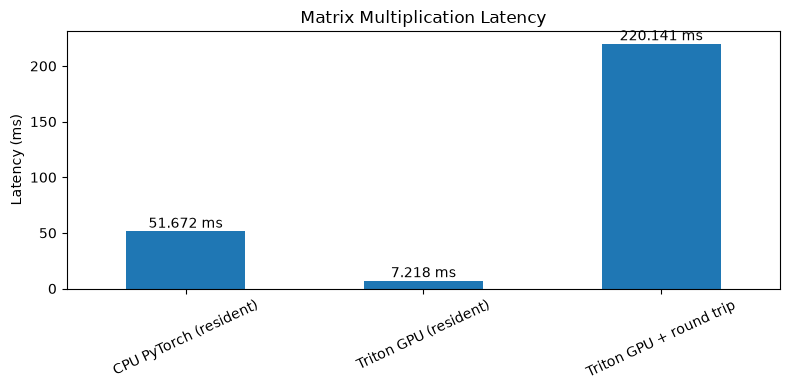

In [6]:
# Create the source matrices on the CPU, then make persistent GPU copies.
a_cpu = torch.randn((MATRIX_ROWS, MATRIX_COLS), dtype=MATRIX_DTYPE)
b_cpu = torch.randn_like(a_cpu)
c_cpu = torch.empty_like(a_cpu)
c_from_gpu = torch.empty_like(a_cpu)

a_gpu = torch.empty_like(a_cpu, device=DEVICE)
b_gpu = torch.empty_like(b_cpu, device=DEVICE)
c_gpu = torch.empty_like(a_gpu)
a_gpu.copy_(a_cpu)
b_gpu.copy_(b_cpu)

# Warm up both paths. The first Triton call compiles the kernel and is intentionally not timed.
for _ in range(3):
    torch.addcmul(a_cpu, a_cpu, b_cpu, out=c_cpu)
launch_matrix_addcmul(a_gpu, b_gpu, c_gpu, MATRIX_BLOCK_SIZE, MATRIX_NUM_WARPS)
torch.cuda.synchronize()

# CPU timing uses wall-clock time because CPU operations are synchronous.
cpu_samples_ms = []
for _ in range(10):
    start = time.perf_counter()
    torch.addcmul(a_cpu, a_cpu, b_cpu, out=c_cpu)
    cpu_samples_ms.append((time.perf_counter() - start) * 1e3)
cpu_ms = float(np.median(cpu_samples_ms))

# Triton uses CUDA-event timing. Inputs and output already reside in GPU memory.
triton_kernel_ms = float(triton.testing.do_bench(
    lambda: launch_matrix_addcmul(
        a_gpu, b_gpu, c_gpu, MATRIX_BLOCK_SIZE, MATRIX_NUM_WARPS
    ),
    warmup=100,
    rep=300,
))

# Wall-clock the full CPU -> GPU -> Triton -> CPU path. Buffers stay allocated.
round_trip_samples_ms = []
for _ in range(7):
    torch.cuda.synchronize()
    start = time.perf_counter()
    a_gpu.copy_(a_cpu)
    b_gpu.copy_(b_cpu)
    launch_matrix_addcmul(a_gpu, b_gpu, c_gpu, MATRIX_BLOCK_SIZE, MATRIX_NUM_WARPS)
    c_from_gpu.copy_(c_gpu)
    torch.cuda.synchronize()
    round_trip_samples_ms.append((time.perf_counter() - start) * 1e3)
triton_round_trip_ms = float(np.median(round_trip_samples_ms))

# Check the actual GPU result against the CPU reference before trusting any timing.
c_from_gpu.copy_(c_gpu)
torch.testing.assert_close(c_from_gpu, c_cpu, rtol=1e-5, atol=1e-6)
max_abs_error = (c_from_gpu - c_cpu).abs().max().item()

matrix_latency_df = pd.DataFrame([
    {"path": "CPU PyTorch (resident)", "latency (ms)": cpu_ms},
    {"path": "Triton GPU (resident)", "latency (ms)": triton_kernel_ms},
    {"path": "Triton GPU + round trip", "latency (ms)": triton_round_trip_ms},
])

matrix_latency_df["difference vs CPU (ms)"] = matrix_latency_df["latency (ms)"] - cpu_ms
matrix_latency_df["speedup vs CPU"] = cpu_ms / matrix_latency_df["latency (ms)"]

print(f"Correctness passed; maximum absolute error = {max_abs_error:.3e}")

ax = matrix_latency_df.plot(
    x="path",
    y="latency (ms)",
    kind="bar",
    legend=False,
    figsize=(8, 4),
    title="Matrix Multiplication Latency",
)

ax.set_xlabel("")
ax.set_ylabel("Latency (ms)")
ax.tick_params(axis="x", rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f ms")

plt.tight_layout()
plt.show()


In [ ]:
ax = matrix_latency_df.plot.bar(
    x="path", y="latency (ms)",
    figsize=(9, 4.5), legend=False, color=["#4c78a8", "#f58518", "#e45756"],
)
ax.set_title("CPU vs Triton latency for C = A + A × B")
ax.set_xlabel("")
ax.set_ylabel("median latency (ms)")
ax.grid(axis="y", alpha=0.25)
ax.bar_label(ax.containers[0], fmt="%.3f ms", padding=3)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

if triton_round_trip_ms > cpu_ms:
    print("Observation: the GPU kernel is fast, but transfers make this one-off operation slower than CPU.")
else:
    print("Observation: even including transfers, this matrix is large enough for the GPU path to win.")
print("For an LLM, tensors normally remain on the GPU across many kernels, so resident latency is the relevant hot-path number.")

del a_cpu, b_cpu, c_cpu, c_from_gpu, a_gpu, b_gpu, c_gpu
torch.cuda.empty_cache()


## What to try next

1. Re-run the SM-ID probe while another CUDA workload is active and compare the distribution.
2. Change `N` in the vector-add benchmark. Tiny arrays expose launch overhead; large arrays expose VRAM bandwidth.
3. Try `BLOCK_SIZE=2048` with different `num_warps` values. A logical tile may exceed the physical thread count because Triton threads process multiple elements.
4. Search the PTX for `ld.global`, `st.global`, and `add`. Then find their native SASS counterparts.
5. Change `MATRIX_ROWS` and `MATRIX_COLS` to find the size where GPU resident execution becomes faster than CPU.
6. Compare resident and round-trip latency to quantify the PCIe transfer penalty.
7. Re-run live `nvidia-smi` before and after the matrix benchmarks to watch clocks, temperature, and power state move.

The useful mental model is: **the grid supplies independent programs/blocks; each SM keeps several resident when resources allow; each block has one or more 32-thread warps; and launch shape determines how much scheduling and memory latency can be hidden.**
